# AChE-QSAR : ML Pipeline for Acetylcholinesterase Bioactivity Prediction


This notebook presents the QSAR workflow for predicting the inhibitory activity of small molecules against Acetylcholinesterase (AChE) using public ChEMBL bioactivity data. The pipeline combines data curation, duplicate-consensus filtering, RDKit descriptors and molecular fingerprints, scaffold-aware validation, model benchmarking, hyperparameter tuning, conformal prediction intervals, applicability-domain analysis, and nearest-neighbor analog search. The goal is to build a predictive and screening-ready model that is not only accurate, but also more reliable, interpretable, and useful for early-stage drug discovery.

In [1]:
import sys
!{sys.executable} -m pip install --upgrade pip -q
!{sys.executable} -m pip install rdkit requests scikit-learn joblib matplotlib pandas numpy scipy -q

In [2]:
# LIBRARIES

import os
import math
import json
import time
import joblib
import requests
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen, AllChem, DataStructs, MACCSkeys
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

In [3]:
# SETTINGS

SEED = 42
np.random.seed(SEED)

TARGET_CHEMBL_ID = "CHEMBL220"
STANDARD_TYPE = "IC50"

MAX_RECORDS = 1200
TEST_SIZE = 0.20
CALIBRATION_SIZE = 0.15

MORGAN_BITS = 256
MORGAN_RADIUS = 2

MIN_VARIANCE = 0.0
CORR_THRESHOLD = 0.98

N_REPEATS_SCAFFOLD = 3
TOP_N_ANALOGS = 5

OUTLIER_LOW = 3.0
OUTLIER_HIGH = 12.5
DUPLICATE_STD_THRESHOLD = 1.0

EXPORT_PREFIX = f"ache_v31_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

In [4]:
# API FETCH

def fetch_chembl_activities(target_chembl_id="CHEMBL220", standard_type="IC50", max_records=1200):
    base_url = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
    limit = 200
    offset = 0
    rows = []

    while True:
        params = {
            "target_chembl_id": target_chembl_id,
            "standard_type": standard_type,
            "limit": limit,
            "offset": offset
        }

        r = requests.get(base_url, params=params, timeout=60)
        r.raise_for_status()
        data = r.json()
        batch = data.get("activities", [])

        if not batch:
            break

        rows.extend(batch)

        if len(rows) >= max_records:
            rows = rows[:max_records]
            break

        if not data.get("page_meta", {}).get("next"):
            break

        offset += limit
        time.sleep(0.05)

    return pd.DataFrame(rows)

In [5]:
# CHEMISTRY HELPERS

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except Exception:
        return None

def mol_from_smiles(smiles):
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None

def standard_value_nm_to_pic50(v):
    try:
        v = float(v)
        if v <= 0:
            return np.nan
        return 9.0 - np.log10(v)
    except Exception:
        return np.nan

def scaffold_from_smiles(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return "NO_SCAFFOLD"
    try:
        s = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
        return s if s != "" else "NO_SCAFFOLD"
    except Exception:
        return "NO_SCAFFOLD"

def lipinski_violations(mol):
    v = 0
    if Descriptors.MolWt(mol) > 500:
        v += 1
    if Crippen.MolLogP(mol) > 5:
        v += 1
    if Lipinski.NumHDonors(mol) > 5:
        v += 1
    if Lipinski.NumHAcceptors(mol) > 10:
        v += 1
    return v

def calc_descriptors(mol):
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "NumHDonors": Lipinski.NumHDonors(mol),
        "NumHAcceptors": Lipinski.NumHAcceptors(mol),
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": Lipinski.RingCount(mol),
        "HeavyAtomCount": Lipinski.HeavyAtomCount(mol),
        "FractionCSP3": Descriptors.FractionCSP3(mol),
        "NHOHCount": Lipinski.NHOHCount(mol),
        "NOCount": Lipinski.NOCount(mol),
        "NumValenceElectrons": Descriptors.NumValenceElectrons(mol),
        "MaxPartialCharge": Descriptors.MaxPartialCharge(mol),
        "MinPartialCharge": Descriptors.MinPartialCharge(mol),
        "MolMR": Crippen.MolMR(mol),
        "NumAromaticRings": Lipinski.NumAromaticRings(mol),
        "NumAliphaticRings": Lipinski.NumAliphaticRings(mol),
        "NumSaturatedRings": Lipinski.NumSaturatedRings(mol),
        "LabuteASA": Descriptors.LabuteASA(mol),
        "BalabanJ": Descriptors.BalabanJ(mol),
        "BertzCT": Descriptors.BertzCT(mol),
        "Chi0v": Descriptors.Chi0v(mol),
        "Chi1v": Descriptors.Chi1v(mol),
        "Kappa1": Descriptors.Kappa1(mol),
        "Kappa2": Descriptors.Kappa2(mol),
        "Kappa3": Descriptors.Kappa3(mol),
    }

def morgan_fp_array(mol, radius=2, n_bits=256):
    arr = np.zeros((n_bits,), dtype=np.int8)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def morgan_fp_object(mol, radius=2, n_bits=256):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)

def maccs_fp_array(mol):
    arr = np.zeros((167,), dtype=np.int8)
    fp = MACCSkeys.GenMACCSKeys(mol)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

In [6]:
# DATA CLEANING + DUPLICATE CONSENSUS

def clean_activity_data(df_raw):
    keep_cols = [
        "molecule_chembl_id",
        "canonical_smiles",
        "standard_value",
        "standard_units",
        "standard_relation",
        "standard_type",
        "pchembl_value",
        "assay_chembl_id",
        "target_chembl_id",
        "document_chembl_id"
    ]
    keep_cols = [c for c in keep_cols if c in df_raw.columns]
    df = df_raw[keep_cols].copy()

    df = df[df["canonical_smiles"].notna()].copy()

    if "standard_value" in df.columns:
        df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
    if "pchembl_value" in df.columns:
        df["pchembl_value"] = pd.to_numeric(df["pchembl_value"], errors="coerce")

    if "standard_relation" in df.columns:
        df = df[
            df["standard_relation"].isin(["=", "'='", None, np.nan]) |
            df["standard_relation"].isna()
        ].copy()

    if "standard_type" in df.columns:
        df = df[df["standard_type"] == "IC50"].copy()

    if "pchembl_value" not in df.columns:
        df["pchembl_value"] = np.nan

    if "standard_units" in df.columns and "standard_value" in df.columns:
        nm_mask = (
            df["pchembl_value"].isna() &
            df["standard_value"].notna() &
            (df["standard_units"].astype(str).str.upper() == "NM")
        )
        df.loc[nm_mask, "pchembl_value"] = df.loc[nm_mask, "standard_value"].apply(standard_value_nm_to_pic50)

    df = df[df["pchembl_value"].notna()].copy()
    df = df[(df["pchembl_value"] >= OUTLIER_LOW) & (df["pchembl_value"] <= OUTLIER_HIGH)].copy()

    df["smiles"] = df["canonical_smiles"].apply(canonicalize_smiles)
    df = df[df["smiles"].notna()].copy()

    grouped = (
        df.groupby(["molecule_chembl_id", "smiles"])["pchembl_value"]
        .agg(["median", "mean", "std", "count", "min", "max"])
        .reset_index()
    )

    grouped["std"] = grouped["std"].fillna(0.0)
    grouped["duplicate_range"] = grouped["max"] - grouped["min"]
    grouped["duplicate_consensus_ok"] = grouped["std"] <= DUPLICATE_STD_THRESHOLD
    grouped = grouped[grouped["duplicate_consensus_ok"]].copy()

    grouped["sample_weight"] = np.log1p(grouped["count"]) / (1.0 + grouped["std"])
    grouped["sample_weight"] = grouped["sample_weight"].clip(lower=0.1)

    grouped = grouped.rename(columns={
        "median": "pIC50",
        "count": "n_measurements",
        "std": "pIC50_std"
    })

    cols = [
        "molecule_chembl_id", "smiles", "pIC50", "mean",
        "pIC50_std", "n_measurements", "duplicate_range",
        "sample_weight"
    ]
    return grouped[cols].reset_index(drop=True)

In [7]:
# FEATURE ENGINEERING

def build_feature_table(df):
    meta_rows = []
    descriptor_rows = []
    morgan_rows = []
    maccs_rows = []
    fp_objects = []

    for _, row in df.iterrows():
        smi = row["smiles"]
        mol = mol_from_smiles(smi)
        if mol is None:
            continue

        try:
            desc = calc_descriptors(mol)
            morgan = morgan_fp_array(mol, radius=MORGAN_RADIUS, n_bits=MORGAN_BITS)
            maccs = maccs_fp_array(mol)
            fp_obj = morgan_fp_object(mol, radius=MORGAN_RADIUS, n_bits=MORGAN_BITS)
            viol = lipinski_violations(mol)

            descriptor_rows.append(desc)
            morgan_rows.append(morgan)
            maccs_rows.append(maccs)
            fp_objects.append(fp_obj)

            meta_rows.append({
                "molecule_chembl_id": row["molecule_chembl_id"],
                "smiles": row["smiles"],
                "pIC50": row["pIC50"],
                "pIC50_std": row["pIC50_std"],
                "n_measurements": row["n_measurements"],
                "duplicate_range": row["duplicate_range"],
                "sample_weight": row["sample_weight"],
                "scaffold": scaffold_from_smiles(row["smiles"]),
                "lipinski_violations": viol,
                "lipinski_ok": viol <= 1
            })
        except Exception:
            continue

    meta_df = pd.DataFrame(meta_rows)
    desc_df = pd.DataFrame(descriptor_rows)
    morgan_df = pd.DataFrame(morgan_rows, columns=[f"MFP_{i}" for i in range(MORGAN_BITS)])
    maccs_df = pd.DataFrame(maccs_rows, columns=[f"MACCS_{i}" for i in range(167)])

    X = pd.concat([desc_df, morgan_df, maccs_df], axis=1)
    y = meta_df["pIC50"].values
    w = meta_df["sample_weight"].values
    return meta_df, X, y, w, fp_objects

In [8]:
# FEATURE FILTERING

def apply_feature_filters(X_train, X_test=None, variance_threshold=0.0, corr_threshold=0.98):
    selector = VarianceThreshold(threshold=variance_threshold)
    X_train_v = pd.DataFrame(
        selector.fit_transform(X_train),
        columns=X_train.columns[selector.get_support()],
        index=X_train.index
    )

    X_test_v = None
    if X_test is not None:
        X_test_v = pd.DataFrame(
            selector.transform(X_test),
            columns=X_train_v.columns,
            index=X_test.index
        )

    corr = X_train_v.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns if any(upper[col] > corr_threshold)]

    X_train_f = X_train_v.drop(columns=drop_cols, errors="ignore")
    X_test_f = None if X_test_v is None else X_test_v.drop(columns=drop_cols, errors="ignore")

    filter_info = {
        "variance_selector": selector,
        "kept_after_variance": X_train_v.columns.tolist(),
        "drop_corr_cols": drop_cols,
        "final_columns": X_train_f.columns.tolist()
    }
    return X_train_f, X_test_f, filter_info

def transform_new_features(X_new, filter_info):
    selector = filter_info["variance_selector"]
    kept = filter_info["kept_after_variance"]
    drop_corr = filter_info["drop_corr_cols"]

    Xv = pd.DataFrame(
        selector.transform(X_new),
        columns=kept,
        index=X_new.index
    )
    return Xv.drop(columns=drop_corr, errors="ignore")

In [9]:
# SPLITS

def scaffold_split_balanced(meta_df, test_size=0.2, seed=42):
    rng = np.random.RandomState(seed)
    groups = meta_df.groupby("scaffold").indices

    scaffold_stats = []
    for scaf, idxs in groups.items():
        idxs = list(idxs)
        scaffold_stats.append({
            "scaffold": scaf,
            "idxs": idxs,
            "size": len(idxs),
            "mean_y": float(meta_df.iloc[idxs]["pIC50"].mean())
        })

    rng.shuffle(scaffold_stats)
    scaffold_stats = sorted(scaffold_stats, key=lambda x: (-x["size"], x["mean_y"]))

    target_test = int(len(meta_df) * test_size)
    train_idx, test_idx = [], []

    for item in scaffold_stats:
        idxs = item["idxs"]
        if len(test_idx) < target_test:
            test_idx.extend(idxs)
        else:
            train_idx.extend(idxs)

    if len(train_idx) == 0 or len(test_idx) == 0:
        idx_all = np.arange(len(meta_df))
        train_idx, test_idx = train_test_split(idx_all, test_size=test_size, random_state=seed)

    return np.array(train_idx), np.array(test_idx)

In [10]:
# MODEL FACTORIES

def get_model_factory(name):
    if name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=150,
            max_depth=16,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1
        )
    elif name == "ExtraTrees":
        return ExtraTreesRegressor(
            n_estimators=150,
            max_depth=16,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1
        )
    elif name == "HistGBR":
        return HistGradientBoostingRegressor(
            max_depth=8,
            learning_rate=0.05,
            max_iter=250,
            random_state=SEED
        )
    elif name == "Ridge":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ])
    else:
        raise ValueError("Unknown model")

def fit_with_optional_weights(model, X, y, sample_weight=None):
    if sample_weight is None:
        model.fit(X, y)
        return model

    try:
        model.fit(X, y, sample_weight=sample_weight)
        return model
    except (TypeError, ValueError):
        pass

    if isinstance(model, Pipeline):
        step_name = list(model.named_steps.keys())[-1]
        try:
            model.fit(X, y, **{f"{step_name}__sample_weight": sample_weight})
            return model
        except (TypeError, ValueError):
            pass

    model.fit(X, y)
    return model

def predict_ensemble(models, weights, X):
    preds = np.column_stack([m.predict(X) for m in models])
    w = np.array(weights, dtype=float)
    w = w / w.sum()
    return preds @ w

def regression_metrics(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred)
    }

In [11]:
# MODEL BENCHMARK

def repeated_scaffold_benchmark(meta_df, X, y, w, repeats=3):
    model_names = ["RandomForest", "ExtraTrees", "HistGBR", "Ridge"]
    all_rows = []

    for rep in range(repeats):
        tr_idx, te_idx = scaffold_split_balanced(meta_df, test_size=TEST_SIZE, seed=SEED + rep)

        X_train_raw = X.iloc[tr_idx].reset_index(drop=True)
        X_test_raw = X.iloc[te_idx].reset_index(drop=True)
        y_train = y[tr_idx]
        y_test = y[te_idx]
        w_train = w[tr_idx]

        X_train, X_test, _ = apply_feature_filters(X_train_raw, X_test_raw, MIN_VARIANCE, CORR_THRESHOLD)

        for name in model_names:
            model = get_model_factory(name)
            model = fit_with_optional_weights(model, X_train, y_train, w_train)
            pred_train = model.predict(X_train)
            pred_test = model.predict(X_test)

            row = {
                "repeat": rep + 1,
                "model": name,
                "train_r2": r2_score(y_train, pred_train),
                "test_r2": r2_score(y_test, pred_test),
                "train_rmse": math.sqrt(mean_squared_error(y_train, pred_train)),
                "test_rmse": math.sqrt(mean_squared_error(y_test, pred_test)),
                "train_mae": mean_absolute_error(y_train, pred_train),
                "test_mae": mean_absolute_error(y_test, pred_test),
            }
            all_rows.append(row)

    return pd.DataFrame(all_rows)

In [12]:
# HYPERPARAMETER TUNING

def tune_best_model(model_name, X_train, y_train, w_train):
    if model_name == "RandomForest":
        base = RandomForestRegressor(random_state=SEED, n_jobs=-1)
        param_dist = {
            "n_estimators": randint(100, 300),
            "max_depth": randint(6, 22),
            "min_samples_split": randint(2, 8),
            "min_samples_leaf": randint(1, 4),
            "max_features": ["sqrt", "log2", None]
        }
        fit_kwargs = {"sample_weight": w_train}

    elif model_name == "ExtraTrees":
        base = ExtraTreesRegressor(random_state=SEED, n_jobs=-1)
        param_dist = {
            "n_estimators": randint(100, 300),
            "max_depth": randint(6, 22),
            "min_samples_split": randint(2, 8),
            "min_samples_leaf": randint(1, 4),
            "max_features": ["sqrt", "log2", None]
        }
        fit_kwargs = {"sample_weight": w_train}

    elif model_name == "HistGBR":
        base = HistGradientBoostingRegressor(random_state=SEED)
        param_dist = {
            "max_depth": randint(4, 12),
            "learning_rate": uniform(0.02, 0.12),
            "max_iter": randint(120, 300),
            "min_samples_leaf": randint(10, 40),
            "l2_regularization": uniform(0.0, 1.0)
        }
        fit_kwargs = {"sample_weight": w_train}

    elif model_name == "Ridge":
        base = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ])
        param_dist = {
            "model__alpha": uniform(0.01, 10.0)
        }
        fit_kwargs = {"model__sample_weight": w_train}

    else:
        raise ValueError("Unknown model")

    search = RandomizedSearchCV(
        estimator=base,
        param_distributions=param_dist,
        n_iter=12,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=SEED,
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_train, y_train, **fit_kwargs)
    return search.best_estimator_, search.best_params_

In [13]:
# CONFORMAL CALIBRATION

def fit_conformal_calibration(model, X_train, y_train, w_train, calibration_size=0.15, seed=42):
    idx = np.arange(len(X_train))
    tr_idx, cal_idx = train_test_split(idx, test_size=calibration_size, random_state=seed)

    Xtr = X_train.iloc[tr_idx].reset_index(drop=True)
    ytr = y_train[tr_idx]
    wtr = w_train[tr_idx]

    Xcal = X_train.iloc[cal_idx].reset_index(drop=True)
    ycal = y_train[cal_idx]

    model = fit_with_optional_weights(model, Xtr, ytr, wtr)
    cal_pred = model.predict(Xcal)
    abs_resid = np.abs(ycal - cal_pred)

    q90 = np.quantile(abs_resid, 0.90)
    q95 = np.quantile(abs_resid, 0.95)

    model = fit_with_optional_weights(model, X_train, y_train, w_train)

    return model, {"q90": float(q90), "q95": float(q95)}

def conformal_coverage(y_true, pred, q):
    covered = ((y_true >= pred - q) & (y_true <= pred + q)).mean()
    widths = np.repeat(2 * q, len(y_true))
    return {
        "coverage": float(covered),
        "mean_interval_width": float(widths.mean())
    }

In [14]:
# AD + NOVELTY + UNCERTAINTY

def max_train_similarity(query_fp, train_fps):
    sims = DataStructs.BulkTanimotoSimilarity(query_fp, train_fps)
    return float(np.max(sims)) if len(sims) else 0.0

def compute_similarity_threshold(train_fps):
    sample = train_fps[: min(250, len(train_fps))]
    sims = []
    for i, fp in enumerate(sample):
        others = sample[:i] + sample[i+1:]
        sims.append(max_train_similarity(fp, others) if others else 1.0)
    return float(np.percentile(sims, 5)) if sims else 0.2

def descriptor_range_profile(X_train):
    return {
        "min": X_train.min().to_dict(),
        "max": X_train.max().to_dict()
    }

def descriptor_out_of_range_fraction(X_row, range_profile):
    mins = range_profile["min"]
    maxs = range_profile["max"]
    flags = []
    for c in X_row.index:
        lo = mins.get(c, None)
        hi = maxs.get(c, None)
        if lo is None or hi is None:
            continue
        flags.append((X_row[c] < lo) or (X_row[c] > hi))
    return float(np.mean(flags)) if flags else 0.0

def ensemble_uncertainty(model, X_new):
    if isinstance(model, Pipeline):
        inner = model.named_steps.get("model", None)
        if inner is None:
            return np.full(len(X_new), np.nan)
        model = inner

    if not hasattr(model, "estimators_"):
        return np.full(len(X_new), np.nan)

    preds = np.array([est.predict(X_new) for est in model.estimators_])
    return preds.std(axis=0)

In [15]:
# ANALOGS + BASELINE

def nearest_analogs(query_fp, train_fps, train_meta, k=5):
    sims = DataStructs.BulkTanimotoSimilarity(query_fp, train_fps)
    order = np.argsort(sims)[::-1][:k]
    out = train_meta.iloc[order][["molecule_chembl_id", "smiles", "pIC50"]].copy()
    out["similarity"] = [sims[i] for i in order]
    return out.reset_index(drop=True)

def knn_similarity_baseline(query_fp, train_fps, train_meta, k=5):
    sims = DataStructs.BulkTanimotoSimilarity(query_fp, train_fps)
    order = np.argsort(sims)[::-1][:k]
    top_sims = np.array([sims[i] for i in order], dtype=float)
    top_y = train_meta.iloc[order]["pIC50"].values.astype(float)
    if top_sims.sum() == 0:
        return float(np.mean(top_y))
    return float(np.average(top_y, weights=top_sims))

In [16]:
# PERMUTATION IMPORTANCE

def get_permutation_importance(model, X_test, y_test, top_n=20):
    try:
        pi = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=SEED, n_jobs=-1)
        imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False).head(top_n)
        return imp
    except Exception:
        return None

In [17]:
# PLOTS

def plot_residual_diagnostics(y_true, y_pred, title_prefix="Model"):
    resid = y_true - y_pred

    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, resid, alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"{title_prefix} Residual vs Predicted")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(resid, bins=30)
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title(f"{title_prefix} Residual Histogram")
    plt.show()

In [18]:
# FETCH + PREP

print("Downloading ChEMBL data...")
df_raw = fetch_chembl_activities(
    target_chembl_id=TARGET_CHEMBL_ID,
    standard_type=STANDARD_TYPE,
    max_records=MAX_RECORDS
)
print("Raw shape:", df_raw.shape)
display(df_raw.head())

print("Cleaning data...")
df_clean = clean_activity_data(df_raw)
print("Cleaned shape:", df_clean.shape)
display(df_clean.head())

print("Building features...")
meta_df, X_full, y_full, w_full, fp_objects = build_feature_table(df_clean)
print("Meta shape:", meta_df.shape)
print("Feature shape:", X_full.shape)

assert len(meta_df) == len(X_full) == len(y_full) == len(w_full), "Length mismatch after feature build"
assert X_full.isna().sum().sum() == 0, "NaN detected in X_full"

Raw shape: (1200, 46)


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.75
1,None,None,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.1
2,None,None,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.3
4,None,None,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.8


Cleaning data...
Cleaned shape: (790, 8)


,molecule_chembl_id,smiles,pIC50,mean,pIC50_std,n_measurements,duplicate_range,sample_weight
0,CHEMBL100366,CN1CC[C@@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3N(C=O)C12,6.110000,6.110000,0.000000,1,0.00000,0.693147
1,CHEMBL101482,CCC(C)CSC(=O)OCC[N+](C)(C)C.[Cl-],3.000000,3.000000,0.000000,1,0.00000,0.693147
2,CHEMBL102077,CCCCCCSC(=O)OCC[N+](C)(C)C.[Cl-],4.050000,4.050000,0.070711,2,0.10000,1.026059
3,CHEMBL102078,CCCCSC(=O)OCC[N+](C)(C)C.[Cl-],3.150515,3.150515,0.212860,2,0.30103,0.905803
4,CHEMBL102226,CCCCCCCSC(=O)OCC[N+](C)(C)C.[Cl-],3.800515,3.800515,0.706378,2,0.99897,0.643827


Building features...


[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerator
[21:22:16] DEPRECATION WARNING: please use MorganGenerat

Meta shape: (790, 10)
Feature shape: (790, 449)


count    790.000000
mean       6.015217
std        1.365692
min        3.000000
25%        5.000000
50%        6.115000
75%        7.000000
max        9.520000
Name: pIC50, dtype: float64


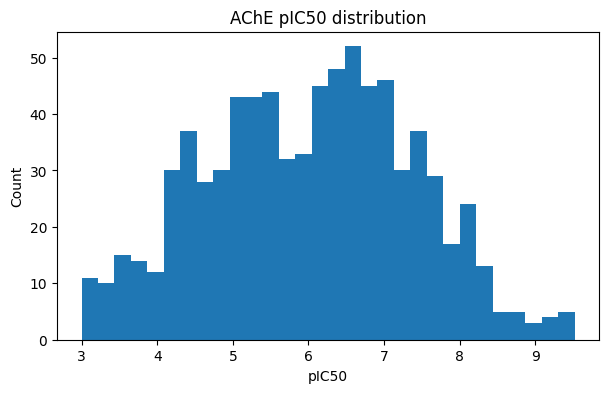

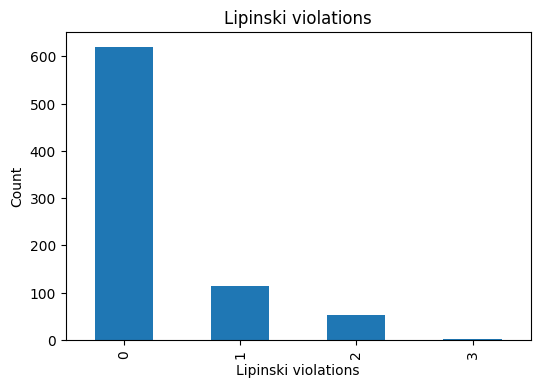

In [19]:
# EDA

print(meta_df["pIC50"].describe())

plt.figure(figsize=(7,4))
plt.hist(meta_df["pIC50"], bins=30)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("AChE pIC50 distribution")
plt.show()

plt.figure(figsize=(6,4))
meta_df["lipinski_violations"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Lipinski violations")
plt.ylabel("Count")
plt.title("Lipinski violations")
plt.show()

In [20]:
# REPEATED SCAFFOLD BENCHMARK

print("Running repeated scaffold benchmark...")
repeat_results = repeated_scaffold_benchmark(meta_df, X_full, y_full, w_full, repeats=N_REPEATS_SCAFFOLD)

summary = (
    repeat_results.groupby("model")
    .agg(
        mean_test_r2=("test_r2", "mean"),
        std_test_r2=("test_r2", "std"),
        mean_test_rmse=("test_rmse", "mean"),
        std_test_rmse=("test_rmse", "std"),
        mean_test_mae=("test_mae", "mean"),
        std_test_mae=("test_mae", "std")
    )
    .sort_values("mean_test_rmse")
    .reset_index()
)
display(summary)

top_models = summary["model"].tolist()[:3]
best_model_name = top_models[0]
print("Top model family:", best_model_name)
print("Ensemble models:", top_models)

Running repeated scaffold benchmark...


,model,mean_test_r2,std_test_r2,mean_test_rmse,std_test_rmse,mean_test_mae,std_test_mae
0,RandomForest,0.357334,4.047920e-03,1.021315,3.215190e-03,0.804452,2.261904e-03
1,HistGBR,0.350132,0.000000e+00,1.027025,0.000000e+00,0.801514,0.000000e+00
2,ExtraTrees,0.345892,2.881393e-03,1.030369,2.269443e-03,0.786671,2.687767e-03
3,Ridge,-0.570672,5.048708e-14,1.596656,2.563774e-14,1.243166,1.491175e-14


Top model family: RandomForest
Ensemble models: ['RandomForest', 'HistGBR', 'ExtraTrees']


In [21]:
# FINAL SPLIT

train_idx, test_idx = scaffold_split_balanced(meta_df, test_size=TEST_SIZE, seed=SEED)

meta_train = meta_df.iloc[train_idx].reset_index(drop=True)
meta_test = meta_df.iloc[test_idx].reset_index(drop=True)

X_train_raw = X_full.iloc[train_idx].reset_index(drop=True)
X_test_raw = X_full.iloc[test_idx].reset_index(drop=True)

y_train = y_full[train_idx]
y_test = y_full[test_idx]
w_train = w_full[train_idx]

train_fps = [fp_objects[i] for i in train_idx]
test_fps = [fp_objects[i] for i in test_idx]

X_train, X_test, filter_info = apply_feature_filters(
    X_train_raw, X_test_raw, MIN_VARIANCE, CORR_THRESHOLD
)

range_profile = descriptor_range_profile(X_train)

print("Filtered train shape:", X_train.shape)
print("Filtered test shape :", X_test.shape)

train_scaf = set(meta_train["scaffold"])
test_scaf = set(meta_test["scaffold"])
print("Unique train scaffolds:", len(train_scaf))
print("Unique test scaffolds :", len(test_scaf))
print("Overlap scaffolds     :", len(train_scaf & test_scaf))

Filtered train shape: (604, 404)
Filtered test shape : (186, 404)
Unique train scaffolds: 293
Unique test scaffolds : 4
Overlap scaffolds     : 0


In [22]:
# TUNE TOP MODELS

fitted_top_models = []
ensemble_weights = []

for model_name in top_models:
    print(f"Tuning {model_name}...")
    mdl, params = tune_best_model(model_name, X_train, y_train, w_train)
    mdl, conformal_info = fit_conformal_calibration(mdl, X_train, y_train, w_train, CALIBRATION_SIZE, SEED)
    pred = mdl.predict(X_test)
    m = regression_metrics(y_test, pred)
    print(model_name, params, m)

    fitted_top_models.append({
        "name": model_name,
        "model": mdl,
        "params": params,
        "conformal": conformal_info,
        "metrics": m
    })
    ensemble_weights.append(1.0 / max(m["rmse"], 1e-6))

Tuning RandomForest...
RandomForest {'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 158} {'r2': 0.3275502851476383, 'rmse': 1.044716423616662, 'mae': 0.8319659750385439}
Tuning HistGBR...
HistGBR {'l2_regularization': np.float64(0.8331949117361643), 'learning_rate': np.float64(0.040803758420932645), 'max_depth': 4, 'max_iter': 283, 'min_samples_leaf': 27} {'r2': 0.253294777988048, 'rmse': 1.1008879283217254, 'mae': 0.8843115126421656}
Tuning ExtraTrees...
ExtraTrees {'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 158} {'r2': 0.2990864297009911, 'rmse': 1.066597961853588, 'mae': 0.8206356776418289}


In [23]:
# ENSEMBLE

ensemble_pred = predict_ensemble([d["model"] for d in fitted_top_models], ensemble_weights, X_test)
ensemble_metrics = regression_metrics(y_test, ensemble_pred)
print("Weighted ensemble metrics:", ensemble_metrics)

single_best = min(fitted_top_models, key=lambda d: d["metrics"]["rmse"])
use_ensemble = ensemble_metrics["rmse"] < single_best["metrics"]["rmse"]

if use_ensemble:
    final_predictor_name = "WeightedEnsemble"
    final_conformal = {
        "q90": float(np.quantile(np.abs(y_test - ensemble_pred), 0.90)),
        "q95": float(np.quantile(np.abs(y_test - ensemble_pred), 0.95))
    }
    final_test_pred = ensemble_pred
else:
    final_predictor_name = single_best["name"]
    final_conformal = single_best["conformal"]
    final_test_pred = single_best["model"].predict(X_test)

print("Final predictor:", final_predictor_name)

Weighted ensemble metrics: {'r2': 0.3475715324721329, 'rmse': 1.0290464208875962, 'mae': 0.8114514755217004}
Final predictor: WeightedEnsemble


In [24]:
# COVERAGE CHECK

cov90 = conformal_coverage(y_test, final_test_pred, final_conformal["q90"])
cov95 = conformal_coverage(y_test, final_test_pred, final_conformal["q95"])
print("Conformal 90% check:", cov90)
print("Conformal 95% check:", cov95)

Conformal 90% check: {'coverage': 0.8978494623655914, 'mean_interval_width': 3.456178618814864}
Conformal 95% check: {'coverage': 0.946236559139785, 'mean_interval_width': 4.295133085797658}


In [25]:
# PERMUTATION IMPORTANCE

perm_imp = None
if not use_ensemble:
    perm_imp = get_permutation_importance(single_best["model"], X_test, y_test, top_n=20)
    if perm_imp is not None:
        plt.figure(figsize=(8,6))
        perm_imp.sort_values().plot(kind="barh")
        plt.xlabel("Permutation importance")
        plt.title(f"Top 20 Features - {single_best['name']}")
        plt.show()

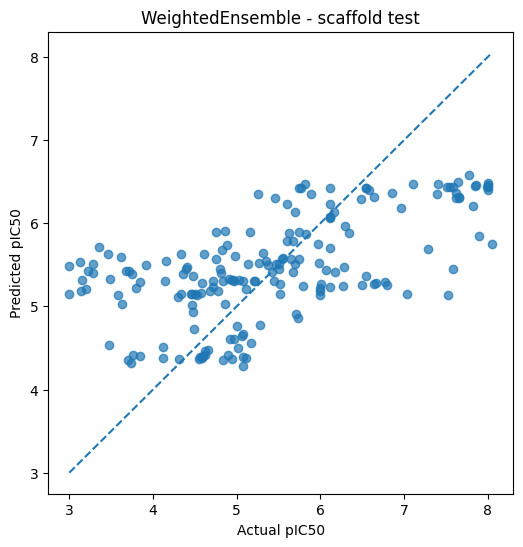

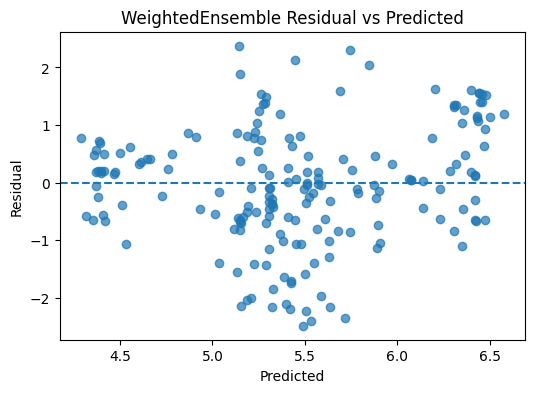

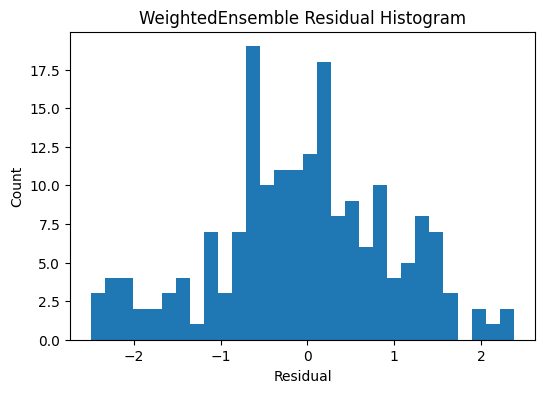

In [26]:
# DIAGNOSTICS

plt.figure(figsize=(6,6))
plt.scatter(y_test, final_test_pred, alpha=0.7)
lims = [min(y_test.min(), final_test_pred.min()), max(y_test.max(), final_test_pred.max())]
plt.plot(lims, lims, "--")
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title(f"{final_predictor_name} - scaffold test")
plt.show()

plot_residual_diagnostics(y_test, final_test_pred, final_predictor_name)

In [27]:
# AD THRESHOLD

ad_similarity_threshold = compute_similarity_threshold(train_fps)
print("AD similarity threshold:", round(ad_similarity_threshold, 3))

AD similarity threshold: 0.568


In [28]:
# REFIT FINAL ARTIFACT ON ALL DATA

X_all_filtered, _, filter_info_all = apply_feature_filters(X_full, None, MIN_VARIANCE, CORR_THRESHOLD)
range_profile_all = descriptor_range_profile(X_all_filtered)

final_models_all = []
final_model_specs = []

for model_name in top_models:
    mdl, params = tune_best_model(model_name, X_all_filtered, y_full, w_full)
    mdl, conformal_info = fit_conformal_calibration(mdl, X_all_filtered, y_full, w_full, CALIBRATION_SIZE, SEED)
    final_models_all.append(mdl)
    final_model_specs.append({
        "name": model_name,
        "params": params,
        "conformal": conformal_info
    })

artifact = {
    "target_chembl_id": TARGET_CHEMBL_ID,
    "export_prefix": EXPORT_PREFIX,
    "feature_columns_raw": X_full.columns.tolist(),
    "filter_info": filter_info_all,
    "range_profile": range_profile_all,
    "radius": MORGAN_RADIUS,
    "morgan_bits": MORGAN_BITS,
    "top_models": top_models,
    "fitted_models": final_models_all,
    "model_specs": final_model_specs,
    "use_ensemble": use_ensemble,
    "final_predictor_name": final_predictor_name,
    "ensemble_weights": ensemble_weights,
    "final_conformal": final_conformal,
    "ad_similarity_threshold": ad_similarity_threshold,
    "train_fps": fp_objects,
    "train_meta": meta_df[["molecule_chembl_id", "smiles", "pIC50", "n_measurements", "pIC50_std"]].copy(),
    "summary": summary,
    "coverage_90": cov90,
    "coverage_95": cov95
}

joblib.dump(artifact, f"{EXPORT_PREFIX}_model.pkl")
meta_df.to_csv(f"{EXPORT_PREFIX}_dataset.csv", index=False)
summary.to_csv(f"{EXPORT_PREFIX}_benchmark_summary.csv", index=False)

experiment_log = {
    "export_prefix": EXPORT_PREFIX,
    "settings": {
        "TARGET_CHEMBL_ID": TARGET_CHEMBL_ID,
        "MAX_RECORDS": MAX_RECORDS,
        "TEST_SIZE": TEST_SIZE,
        "CALIBRATION_SIZE": CALIBRATION_SIZE,
        "MORGAN_BITS": MORGAN_BITS,
        "MORGAN_RADIUS": MORGAN_RADIUS,
        "OUTLIER_LOW": OUTLIER_LOW,
        "OUTLIER_HIGH": OUTLIER_HIGH,
        "DUPLICATE_STD_THRESHOLD": DUPLICATE_STD_THRESHOLD
    },
    "n_raw": int(len(df_raw)),
    "n_clean": int(len(df_clean)),
    "n_final": int(len(meta_df)),
    "n_features_raw": int(X_full.shape[1]),
    "n_features_filtered_train": int(X_train.shape[1]),
    "top_models": top_models,
    "final_predictor_name": final_predictor_name,
    "use_ensemble": bool(use_ensemble),
    "coverage_90": cov90,
    "coverage_95": cov95,
    "ad_similarity_threshold": ad_similarity_threshold
}

with open(f"{EXPORT_PREFIX}_experiment_log.json", "w") as f:
    json.dump(experiment_log, f, indent=2)

print("Saved files:")
print(f"- {EXPORT_PREFIX}_model.pkl")
print(f"- {EXPORT_PREFIX}_dataset.csv")
print(f"- {EXPORT_PREFIX}_benchmark_summary.csv")
print(f"- {EXPORT_PREFIX}_experiment_log.json")

Saved files:
- ache_v31_20260328_212153_model.pkl
- ache_v31_20260328_212153_dataset.csv
- ache_v31_20260328_212153_benchmark_summary.csv
- ache_v31_20260328_212153_experiment_log.json


In [29]:
# PREDICTION PIPELINE

def featurize_smiles_list(smiles_list, radius=2, morgan_bits=256):
    feature_rows = []
    meta_rows = []
    fps = []
    invalid_smiles = []

    for smi in smiles_list:
        smi = str(smi)
        can = canonicalize_smiles(smi)
        if can is None:
            invalid_smiles.append(smi)
            continue

        mol = mol_from_smiles(can)
        if mol is None:
            invalid_smiles.append(smi)
            continue

        try:
            desc = calc_descriptors(mol)
            morgan = morgan_fp_array(mol, radius=radius, n_bits=morgan_bits)
            maccs = maccs_fp_array(mol)
            fp_obj = morgan_fp_object(mol, radius=radius, n_bits=morgan_bits)
            viol = lipinski_violations(mol)

            row = dict(desc)
            for i, bit in enumerate(morgan):
                row[f"MFP_{i}"] = int(bit)
            for i, bit in enumerate(maccs):
                row[f"MACCS_{i}"] = int(bit)

            feature_rows.append(row)
            meta_rows.append({
                "smiles": can,
                "scaffold": scaffold_from_smiles(can),
                "lipinski_violations": viol,
                "lipinski_ok": viol <= 1
            })
            fps.append(fp_obj)
        except Exception:
            invalid_smiles.append(smi)

    return pd.DataFrame(feature_rows), pd.DataFrame(meta_rows), fps, invalid_smiles

def predict_smiles(smiles_list, artifact_path=None, confidence=0.90):
    if artifact_path is None:
        artifact_path = f"{EXPORT_PREFIX}_model.pkl"

    artifact = joblib.load(artifact_path)

    X_new_raw, meta_new, fps_new, invalid_smiles = featurize_smiles_list(
        smiles_list,
        radius=artifact["radius"],
        morgan_bits=artifact["morgan_bits"]
    )

    if len(X_new_raw) == 0:
        return pd.DataFrame(columns=["smiles", "predicted_pIC50"]), invalid_smiles, {}

    X_new_raw = X_new_raw.reindex(columns=artifact["feature_columns_raw"], fill_value=0)
    X_new = transform_new_features(X_new_raw, artifact["filter_info"])

    if artifact["use_ensemble"]:
        preds = predict_ensemble(artifact["fitted_models"], artifact["ensemble_weights"], X_new)
    else:
        preds = artifact["fitted_models"][0].predict(X_new)

    q = artifact["final_conformal"]["q90"] if confidence <= 0.90 else artifact["final_conformal"]["q95"]
    lower = preds - q
    upper = preds + q

    similarities = [max_train_similarity(fp, artifact["train_fps"]) for fp in fps_new]
    novelty = [1.0 - s for s in similarities]
    in_domain_sim = [s >= artifact["ad_similarity_threshold"] for s in similarities]

    out_of_range_frac = [
        descriptor_out_of_range_fraction(X_new.iloc[i], artifact["range_profile"])
        for i in range(len(X_new))
    ]
    in_domain_desc = [v <= 0.10 for v in out_of_range_frac]
    in_domain = [a and b for a, b in zip(in_domain_sim, in_domain_desc)]

    unc = np.full(len(X_new), np.nan)
    if not artifact["use_ensemble"]:
        try:
            unc = ensemble_uncertainty(artifact["fitted_models"][0], X_new)
        except Exception:
            pass

    analog_baseline = [
        knn_similarity_baseline(fp, artifact["train_fps"], artifact["train_meta"], k=TOP_N_ANALOGS)
        for fp in fps_new
    ]

    out = meta_new.copy()
    out["predicted_pIC50"] = preds
    out["pi_lower"] = lower
    out["pi_upper"] = upper
    out["max_train_similarity"] = similarities
    out["novelty_score"] = novelty
    out["descriptor_out_of_range_fraction"] = out_of_range_frac
    out["in_domain_similarity"] = in_domain_sim
    out["in_domain_descriptor"] = in_domain_desc
    out["in_applicability_domain"] = in_domain
    out["ensemble_uncertainty_std"] = unc
    out["analog_baseline_pIC50"] = analog_baseline
    out["delta_vs_analog_baseline"] = out["predicted_pIC50"] - out["analog_baseline_pIC50"]

    out["warning_low_similarity"] = out["max_train_similarity"] < artifact["ad_similarity_threshold"]
    out["warning_high_uncertainty"] = out["ensemble_uncertainty_std"].fillna(0) > out["ensemble_uncertainty_std"].fillna(0).median()
    out["warning_many_lipinski_violations"] = out["lipinski_violations"] >= 2
    out["warning_descriptor_oor"] = out["descriptor_out_of_range_fraction"] > 0.10
    out["warning_large_model_vs_neighbor_gap"] = out["delta_vs_analog_baseline"].abs() > 1.5

    penalty_unc = out["ensemble_uncertainty_std"].fillna(0)
    penalty_domain = (~out["in_applicability_domain"]).astype(int) * 1.0
    penalty_lip = out["lipinski_violations"] * 0.2
    penalty_oor = out["descriptor_out_of_range_fraction"] * 2.0

    out["screening_score"] = (
        out["predicted_pIC50"]
        - penalty_unc
        - penalty_domain
        - penalty_lip
        - penalty_oor
    )

    analogs_dict = {}
    for i, fp in enumerate(fps_new):
        analogs_dict[out.loc[i, "smiles"]] = nearest_analogs(
            fp, artifact["train_fps"], artifact["train_meta"], k=TOP_N_ANALOGS
        )

    out = out.sort_values("screening_score", ascending=False).reset_index(drop=True)
    return out, invalid_smiles, analogs_dict

In [30]:
# EXAMPLE PREDICTION

example_smiles = [
    "CCN(CC)CCOC(=O)C1=CC=CC=C1Cl",
    "CN1CCC(CC1)OC2=NC=CC(=C2)Cl",
    "CCOC(=O)NCCC1=CNc2c1cc(OC)cc2"
]

pred_df, invalid, analogs = predict_smiles(example_smiles, confidence=0.90)

print("Invalid SMILES:", invalid)
display(pred_df)

for smi, analog_df in analogs.items():
    print(f"\nNearest analogs for: {smi}")
    display(analog_df)

Invalid SMILES: []


[21:26:26] DEPRECATION WARNING: please use MorganGenerator
[21:26:26] DEPRECATION WARNING: please use MorganGenerator
[21:26:26] DEPRECATION WARNING: please use MorganGenerator
[21:26:26] DEPRECATION WARNING: please use MorganGenerator
[21:26:26] DEPRECATION WARNING: please use MorganGenerator
[21:26:26] DEPRECATION WARNING: please use MorganGenerator


,smiles,scaffold,lipinski_violations,lipinski_ok,predicted_pIC50,pi_lower,pi_upper,max_train_similarity,novelty_score,descriptor_out_of_range_fraction,...,in_applicability_domain,ensemble_uncertainty_std,analog_baseline_pIC50,delta_vs_analog_baseline,warning_low_similarity,warning_high_uncertainty,warning_many_lipinski_violations,warning_descriptor_oor,warning_large_model_vs_neighbor_gap,screening_score
0,CN1CCC(Oc2cc(Cl)ccn2)CC1,c1ccc(OC2CCNCC2)nc1,0,True,5.845148,4.117059,7.573237,0.369565,0.630435,0.0,...,False,NaN,8.150520,-2.305372,True,False,False,False,True,4.845148
1,CCOC(=O)NCCc1c[nH]c2ccc(OC)cc12,c1ccc2[nH]ccc2c1,0,True,5.801988,4.073899,7.530077,0.392857,0.607143,0.0,...,False,NaN,5.768206,0.033782,True,False,False,False,False,4.801988
2,CCN(CC)CCOC(=O)c1ccccc1Cl,c1ccccc1,0,True,4.892581,3.164491,6.620670,0.456522,0.543478,0.0,...,False,NaN,6.660065,-1.767485,True,False,False,False,True,3.892581



Nearest analogs for: CCN(CC)CCOC(=O)c1ccccc1Cl


,molecule_chembl_id,smiles,pIC50,similarity
0,CHEMBL177052,CCN(CCCCCC(=O)N(C)CCCCCCCCN(C)C(=O)CCCCCN(CC)C...,6.950000,0.456522
1,CHEMBL173935,CC[N+](C)(CCCCCC(=O)N(C)CCCCCCCCN(C)C(=O)CCCCC...,7.710000,0.387755
2,CHEMBL368075,CCCOc1ccccc1CN(CC)CCCCCC(=O)N(C)CCCCCCCCN(C)C(...,7.470000,0.377358
3,CHEMBL176585,CCN(CCCCCC(=O)N(C)CCCCCCCCN(C)C(=O)CCCCCN(CC)C...,7.310000,0.369565
4,CHEMBL46151,CCN(CC)CCS/C(=N\O)C(=O)c1ccc(OC)cc1,3.585027,0.352941



Nearest analogs for: CN1CCC(Oc2cc(Cl)ccn2)CC1


,molecule_chembl_id,smiles,pIC50,similarity
0,CHEMBL348318,CN1CCC(C2Cc3ccccc3C2=O)CC1,5.48,0.369565
1,CHEMBL155945,CN1CCC(CC/C=C2\Cc3ccccc3C2=O)CC1,9.09,0.346154
2,CHEMBL155746,CN1CCC(/C=C/C=C2\Cc3ccccc3C2=O)CC1,8.52,0.346154
3,CHEMBL345847,CN1CCC(CCN2C(=O)c3ccccc3C2=O)CC1,9.05,0.340426
4,CHEMBL263322,CN1CCC(CCCC2Cc3ccccc3C2=O)CC1,8.82,0.340000



Nearest analogs for: CCOC(=O)NCCc1c[nH]c2ccc(OC)cc12


,molecule_chembl_id,smiles,pIC50,similarity
0,CHEMBL543220,CCCNC(=O)Oc1ccc2c(c1)C(N)CC2.Cl,5.83,0.392857
1,CHEMBL340216,COc1ccc2[nH]cc(/C=C3\CN(Cc4ccccc4)CCC3=O)c2c1,5.22,0.380952
2,CHEMBL542018,CCNC(=O)Oc1ccc2c(c1)C(N)CC2.Cl,4.75,0.363636
3,CHEMBL284369,CCCCCCNC(=O)Oc1ccc2c(c1)[C@@H]1CCN(CC)C1C2,6.68,0.354839
4,CHEMBL32453,CCCCCCCNC(=O)Oc1ccc2c(c1)[C@@H]1CCN(CC)C1C2,6.42,0.354839
